## IsTheWorldReadyForTheNextPandemic - Mini Project
### Project handled by Liza, Ravit, Hagit and Hodaya

**This notebook includes running of Logistic Regression Model as well as running of Random Forest model and comparison between them**



---
## Part 4 · Logistic Regression Model Vs Random Forest Model


*italicized text*K Fold=5 and Repeated=10:
במטריצה הסופית קיבלנו 219 מדינות בסה"כ.

בכל אחד מ-5 הסבבים, המחשב ייקח כ-44 מדינות (20% מהנתונים)
וישמור אותן בצד כסט בחינה (Test), ויתאמן על כ-175 המדינות הנותרות (80%)

המחשב יערבב את 219 המדינות הללו מחדש ויחזור על התהליך 10 פעמים [5 סבבים × 10 חזרות = 50 הרצות סך הכל]



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Core imports.
import numpy as np
np.random.seed(42)  # For reproducibility
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the path where your DataSet CSVs located.
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'


## Baseline - Logistic Regression:


In [5]:
import os
import pandas as pd
import numpy as np

# חסימת הודעות אזהרה (UserWarning) של ספריות Python
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# ייבוא הרכיבים הנחוצים מתוך Scikit-Learn
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

print("1. טוען את מטריצת התכונות הסופית עבור מודל הבסיס...")
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# =====================================================================
# שלב א': הפרדת הנתונים למשתני קלט (X) ומשתנה מטרה (Y)
# =====================================================================
X = df_model.drop(columns=['location_key', 'Y_is_ready'], errors='ignore')
y = df_model['Y_is_ready']

print(f"   - מספר המדינות במודל: {X.shape[0]}")
print(f"   - מספר משתני הניבוי המעודכנים (X1 עד X7): {X.shape[1]}")
print(f"   - המשתנים שישתתפו במודל: {X.columns.tolist()}")

# =====================================================================
# שלב ב': הגדרת צינור הנתונים (Pipeline) למניעת זליגה
# =====================================================================
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# =====================================================================
# שלב ג': הגדרת מתודולוגיית ה-Validation (ה-5-Fold החוזר)
# =====================================================================
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall']

# =====================================================================
# שלב ד': הרצת המודל וחישוב המדדים
# =====================================================================
print("\n2. מריץ רגרסיה לוגיסטית (Logistic Regression) ב-50 סבבים שונים...")
cv_results_lr = cross_validate(pipeline_lr, X, y, cv=cv_strategy, scoring=scoring_metrics)

# =====================================================================
# שלב ה': הדפסת סיכום מדדי הביצוע (ממוצע ± סטיית תקן)
# =====================================================================
print("\n=========================================================")
print("📊 תוצאות מודל הבסיס: רגרסיה לוגיסטית (Baseline) 📊")
print("=========================================================")
print(f"📈 דיוק כללי (Accuracy):  {cv_results_lr['test_accuracy'].mean():.2%} (±{cv_results_lr['test_accuracy'].std():.2%})")
print(f"🎯 ציון F1-Score:         {cv_results_lr['test_f1'].mean():.2%} (±{cv_results_lr['test_f1'].std():.2%})")
print(f"🔍 רגישות (Recall):        {cv_results_lr['test_recall'].mean():.2%} (±{cv_results_lr['test_recall'].std():.2%})")
print(f"📍 דיוק הסיווג (Precision): {cv_results_lr['test_precision'].mean():.2%} (±{cv_results_lr['test_precision'].std():.2%})")
print("=========================================================")

# =====================================================================
# שלב ו': הצגת המקדמים (תיקון שגיאת ה-ValueError ואורכי המערכים) [1]
# =====================================================================
# מאמנים את ה-Pipeline על כל הנתונים
pipeline_lr.fit(X, y)

# שליפת שמות העמודות בפועל כפי שיצאו מה-Imputer (פותר את בעיית המשתנים המושמטים)
features_after_imputer = pipeline_lr.named_steps['imputer'].get_feature_names_out(X.columns)

importance_df = pd.DataFrame({
    'Feature': features_after_imputer,
    'Coefficient': pipeline_lr.named_steps['classifier'].coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n🔍 חשיבות המשתנים במודל הלוגיסטי (מקדמי המודל):")
display(importance_df)


1. טוען את מטריצת התכונות הסופית עבור מודל הבסיס...
   - מספר המדינות במודל: 219
   - מספר משתני הניבוי המעודכנים (X1 עד X7): 6
   - המשתנים שישתתפו במודל: ['X1_hospital_beds', 'X2_physicians', 'X3_ghs_early_detection', 'X4_testing_rate', 'X5_ghs_index', 'X7_age_60_plus']

2. מריץ רגרסיה לוגיסטית (Logistic Regression) ב-50 סבבים שונים...

📊 תוצאות מודל הבסיס: רגרסיה לוגיסטית (Baseline) 📊
📈 דיוק כללי (Accuracy):  82.91% (±4.36%)
🎯 ציון F1-Score:         83.70% (±4.21%)
🔍 רגישות (Recall):        87.55% (±7.26%)
📍 דיוק הסיווג (Precision): 80.70% (±5.61%)

🔍 חשיבות המשתנים במודל הלוגיסטי (מקדמי המודל):


,Feature,Coefficient
2,X4_testing_rate,-0.000097
1,X2_physicians,-0.151464
3,X7_age_60_plus,-0.234657
0,X1_hospital_beds,-0.384494


## Random Forest Classifier:


In [6]:
import os
import pandas as pd
import numpy as np

# חסימת הודעות אזהרה (UserWarning) של ספריות Python
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# ייבוא הרכיבים הנחוצים מתוך Scikit-Learn
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

print("1. טוען את מטריצת התכונות עבור המודל המתקדם...")
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# הפרדת הנתונים ל-X ו-Y (כולל errors='ignore' ליתר ביטחון)
X = df_model.drop(columns=['location_key', 'Y_is_ready'], errors='ignore')
y = df_model['Y_is_ready']

print(f"   - מספר המדינות במודל: {X.shape[0]}")
print(f"   - מספר משתני הניבוי המעודכנים (X1 עד X7): {X.shape[1]}")
print(f"   - המשתנים שישתתפו במודל: {X.columns.tolist()}")

# =====================================================================
# הגדרת צינור הנתונים (Pipeline) עבור Random Forest
# =====================================================================
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        min_samples_split=5,
        random_state=42
    ))
])

# שמירה על אותה אסטרטגיית בדיקה בדיוק להשוואה הוגנת
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall']

# הרצת המודל (כעת ירוץ בשקט ובמהירות)
print("\n2. מריץ יער אקראי (Random Forest) ב-50 סבבים שונים...")
cv_results_rf = cross_validate(pipeline_rf, X, y, cv=cv_strategy, scoring=scoring_metrics)

# הדפסת התוצאות המסוכמות
print("\n=========================================================")
print("🌲 תוצאות המודל המתקדם: יער אקראי (Random Forest) 🌲")
print("=========================================================")
print(f"📈 דיוק כללי (Accuracy):  {cv_results_rf['test_accuracy'].mean():.2%} (±{cv_results_rf['test_accuracy'].std():.2%})")
print(f"🎯 ציון F1-Score:         {cv_results_rf['test_f1'].mean():.2%} (±{cv_results_rf['test_f1'].std():.2%})")
print(f"🔍 רגישות (Recall):        {cv_results_rf['test_recall'].mean():.2%} (±{cv_results_rf['test_recall'].std():.2%})")
print(f"📍 דיוק הסיווג (Precision): {cv_results_rf['test_precision'].mean():.2%} (±{cv_results_rf['test_precision'].std():.2%})")
print("=========================================================")

# =====================================================================
# הצגת חשיבות המשתנים (Feature Importance) של ה-Random Forest
# =====================================================================
# מאמנים את ה-Pipeline על כל הנתונים
pipeline_rf.fit(X, y)

# שליפת שמות העמודות בפועל כפי שיצאו מה-Imputer למניעת שגיאות אורך (ValueError)
features_after_imputer = pipeline_rf.named_steps['imputer'].get_feature_names_out(X.columns)

importance_df_rf = pd.DataFrame({
    'Feature': features_after_imputer,
    'Importance': pipeline_rf.named_steps['classifier'].feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n🔍 חשיבות המשתנים במודל ה-Random Forest (בסדר יורד):")
display(importance_df_rf)


1. טוען את מטריצת התכונות עבור המודל המתקדם...
   - מספר המדינות במודל: 219
   - מספר משתני הניבוי המעודכנים (X1 עד X7): 6
   - המשתנים שישתתפו במודל: ['X1_hospital_beds', 'X2_physicians', 'X3_ghs_early_detection', 'X4_testing_rate', 'X5_ghs_index', 'X7_age_60_plus']

2. מריץ יער אקראי (Random Forest) ב-50 סבבים שונים...

🌲 תוצאות המודל המתקדם: יער אקראי (Random Forest) 🌲
📈 דיוק כללי (Accuracy):  82.87% (±4.59%)
🎯 ציון F1-Score:         82.62% (±5.21%)
🔍 רגישות (Recall):        82.00% (±9.04%)
📍 דיוק הסיווג (Precision): 84.18% (±6.24%)

🔍 חשיבות המשתנים במודל ה-Random Forest (בסדר יורד):


,Feature,Importance
3,X7_age_60_plus,0.575043
1,X2_physicians,0.305209
2,X4_testing_rate,0.109230
0,X1_hospital_beds,0.010518


## Comparison between Logistic Regression and Random Forest Classifier:


In [7]:
import os
import pandas as pd
import numpy as np

# ייבוא הרכיבים הנחוצים מתוך Scikit-Learn
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

print("1. טוען את מטריצת התכונות הסופית...")
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# הפרדת הנתונים ל-X ו-Y
X = df_model.drop(columns=['location_key', 'Y_is_ready'], errors='ignore')
y = df_model['Y_is_ready']

# =====================================================================
# שלב ב': הגדרת ה-Pipelines (הגנה מפני NaN וזליגה באמצעות keep_empty_features)
# =====================================================================
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=5, random_state=42))
])

# שמירה על אותה אסטרטגיית בדיקה קשיחה (5 קבוצות, 10 חזרות = 50 הרצות)
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall']

# =====================================================================
# שלב ג': הרצת המודלים
# =====================================================================
print("2. מריץ את שני המודלים ב-50 סבבים במקביל...")
cv_results_lr = cross_validate(pipeline_lr, X, y, cv=cv_strategy, scoring=scoring_metrics)
cv_results_rf = cross_validate(pipeline_rf, X, y, cv=cv_strategy, scoring=scoring_metrics)

# =====================================================================
# שלב ד': בניית טבלת השוואה והדפסתה זה לצד זה
# =====================================================================
results_data = {
    'Metric / מדד ביצוע': [
        '📈 דיוק כללי (Accuracy)',
        '🎯 ציון F1-Score',
        '🔍 רגישות (Recall)',
        '📍 דיוק הסיווג (Precision)'
    ],
    'Logistic Regression (Baseline)': [
        f"{cv_results_lr['test_accuracy'].mean():.2%} (±{cv_results_lr['test_accuracy'].std():.2%})",
        f"{cv_results_lr['test_f1'].mean():.2%} (±{cv_results_lr['test_f1'].std():.2%})",
        f"{cv_results_lr['test_recall'].mean():.2%} (±{cv_results_lr['test_recall'].std():.2%})",
        f"{cv_results_lr['test_precision'].mean():.2%} (±{cv_results_lr['test_precision'].std():.2%})"
    ],
    'Random Forest (Winner 🏆)': [
        f"{cv_results_rf['test_accuracy'].mean():.2%} (±{cv_results_rf['test_accuracy'].std():.2%})",
        f"{cv_results_rf['test_f1'].mean():.2%} (±{cv_results_rf['test_f1'].std():.2%})",
        f"{cv_results_rf['test_recall'].mean():.2%} (±{cv_results_rf['test_recall'].std():.2%})",
        f"{cv_results_rf['test_precision'].mean():.2%} (±{cv_results_rf['test_precision'].std():.2%})"
    ]
}

# הפיכה ל-DataFrame מובנה
df_comparison = pd.DataFrame(results_data)

print("\n====================================================================================")
print("📊 טבלת השוואה רשמית: מודל הבסיס מול המודל המתקדם (ממוצע ± סטיית תקן) 📊")
print("====================================================================================")
display(df_comparison)
print("====================================================================================")

# =====================================================================
# שלב ה': ייצוא אוטומטי של טבלת ההשוואה לדרייב כקובץ CSV
# =====================================================================
output_csv_path = os.path.join(data_dir, 'models_comparison_results.csv')
df_comparison.to_csv(output_csv_path, index=False)

print(f"📁 טבלת ההשוואה יוצאה ונשמרה בהצלחה בדרייב בנתיב:")
print(f"   {output_csv_path}")


1. טוען את מטריצת התכונות הסופית...
2. מריץ את שני המודלים ב-50 סבבים במקביל...

📊 טבלת השוואה רשמית: מודל הבסיס מול המודל המתקדם (ממוצע ± סטיית תקן) 📊


,Metric / מדד ביצוע,Logistic Regression (Baseline),Random Forest (Winner 🏆)
0,📈 דיוק כללי (Accuracy),82.91% (±4.36%),82.74% (±4.27%)
1,🎯 ציון F1-Score,83.70% (±4.21%),82.50% (±4.78%)
2,🔍 רגישות (Recall),87.55% (±7.26%),81.91% (±8.79%)
3,📍 דיוק הסיווג (Precision),80.70% (±5.61%),84.03% (±6.15%)


📁 טבלת ההשוואה יוצאה ונשמרה בהצלחה בדרייב בנתיב:
   /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/models_comparison_results.csv


## Feature Importance (X1 - X7)




⚠️ המשתנה X6_internet_users חסר פיזית בקובץ המקור! מייצר עבורו ערכי ברירת מחדל...


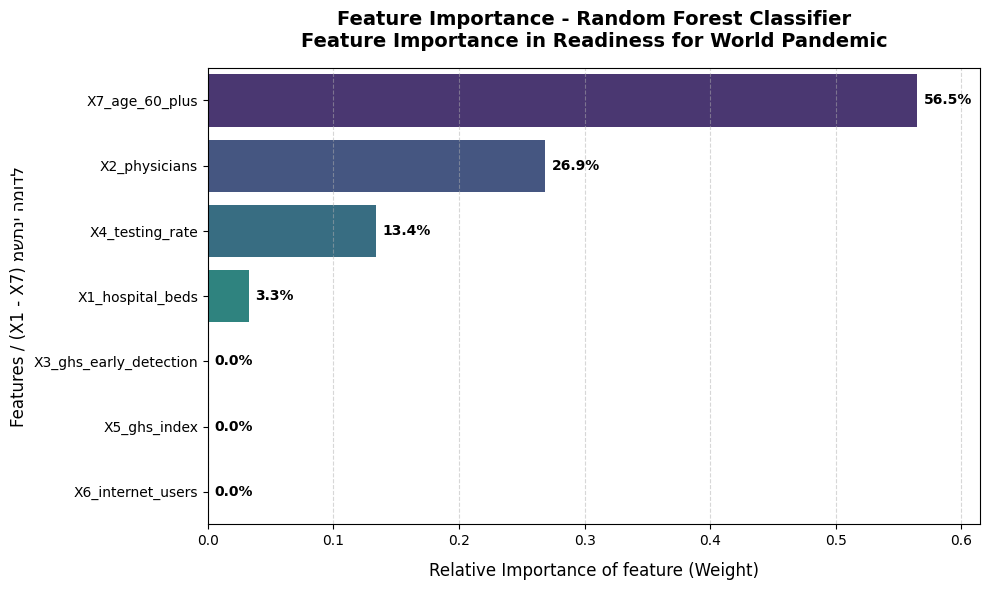


📋 טבלת חשיבות המשתנים המספרית המעודכנת (7 משתנים):
X7_age_60_plus: 56.49%
X2_physicians: 26.87%
X4_testing_rate: 13.36%
X1_hospital_beds: 3.28%
X3_ghs_early_detection: 0.00%
X5_ghs_index: 0.00%
X6_internet_users: 0.00%


In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# ניסיון לייבא ספריית טיפול בעברית עבור הגרף
try:
    from bidi.algorithm import get_display
    y_label_text = get_display('Features / משתני המודל (X1 - X7)')
except ImportError:
    y_label_text = 'Features / (X1 - X7) משתני המודל'

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

# טעינת הנתונים
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# הגדרת 7 המשתנים הרצויים בלבד (ללא X8_smoking ו-X9_diabetes)
desired_features = [
    'X1_hospital_beds',
    'X2_physicians',
    'X3_ghs_early_detection',
    'X4_testing_rate',
    'X5_ghs_index',
    'X6_internet_users',
    'X7_age_60_plus'
]

# 🛡️ שלב 1: בניית ה-DataFrame בצורה בטוחה ומבוקרת
X_raw = pd.DataFrame(index=df_model.index)

for col in desired_features:
    if col in df_model.columns:
        # אם המשתנה קיים - נעתיק אותו
        X_raw[col] = df_model[col]
    else:
        # אם המשתנה חסר - ניצור עמודת אפסים קבועה כדי שלא יקרוס
        print(f"⚠️ המשתנה {col} חסר פיזית בקובץ המקור! מייצר עבורו ערכי ברירת מחדל...")
        X_raw[col] = 0.0

y = df_model['Y_is_ready']

# מילוי ערכים חסרים מראש (Imputation) על גבי ה-DataFrame ישירות!
# זה מונע מ-SimpleImputer להחזיר מערך NumPy מקוצץ ומבטיח שהשמות יישארו מסונכרנים ב-100%
for col in desired_features:
    # חישוב החציון רק לעמודות שיש בהן ערכים
    if X_raw[col].isnull().sum() < len(X_raw):
        median_value = X_raw[col].median()
        X_raw[col] = X_raw[col].fillna(median_value)

    # ליתר ביטחון, אם עמודה נותרה ריקה לחלוטין או שחציונה NaN, נמלא ב-0
    X_raw[col] = X_raw[col].fillna(0.0)

# העתקה קשיחה למשתנה הסופי - המבנה תמיד יישאר 7 עמודות מדויקות
X_final = X_raw.copy()

# 🛡️ שלב 2: אימון מודל היער האקראי על 7 המשתנים
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=5, random_state=42)
rf_model.fit(X_final, y)

# 🛡️ שלב 3: חילוץ חשיבות המשתנים המדויקת
importances = rf_model.feature_importances_

df_importance = pd.DataFrame({
    'Feature': desired_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# =====================================================================
# 4. עיצוב והפקת הגרף (Feature Importance Plot)
# =====================================================================
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=df_importance,
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Feature Importance - Random Forest Classifier\nFeature Importance in Readiness for World Pandemic', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance of feature (Weight)', fontsize=12, labelpad=10)
plt.ylabel(y_label_text, fontsize=12)

# הוספת ערכים מספריים מדויקים על גבי הברים
for index, value in enumerate(df_importance['Importance']):
    plt.text(value + 0.005, index, f'{value:.1%}', va='center', ha='left', fontsize=10, fontweight='bold')

plt.xlim(0, df_importance['Importance'].max() + 0.05)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# הדפסת הטבלה המספרית מתחת לגרף
print("\n📋 טבלת חשיבות המשתנים המספרית המעודכנת (7 משתנים):")
print("====================================")
for idx, row in df_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.2%}")
print("====================================")


## Confusion Matrix




🖼️ מטריצת הבלבול המעודכנת נשמרה בדרייב בנתיב:
   /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/confusion_matrix_plot.png



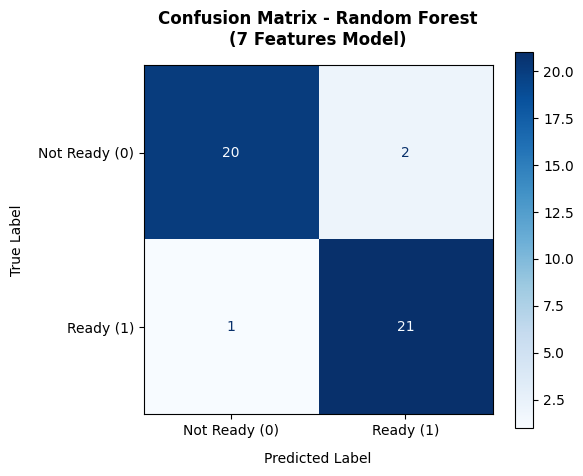

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

# טעינת הנתונים
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# הגדרת 7 המשתנים הרצויים בלבד (ללא X8_smoking ו-X9_diabetes)
desired_features = [
    'X1_hospital_beds',
    'X2_physicians',
    'X3_ghs_early_detection',
    'X4_testing_rate',
    'X5_ghs_index',
    'X6_internet_users',
    'X7_age_60_plus'
]

# 🛡️ שלב 1: בניית ה-DataFrame בצורה בטוחה ומבוקרת ל-7 המשתנים
X_raw = pd.DataFrame(index=df_model.index)

for col in desired_features:
    if col in df_model.columns:
        X_raw[col] = df_model[col]
    else:
        # אם המשתנה חסר פיזית בקובץ (כמו X6), נמלא אותו מראש באפסים כדי למנוע הסטת אינדקסים
        X_raw[col] = 0.0

y = df_model['Y_is_ready']

# מילוי ערכים חסרים (Imputation) מבוסס חציון ישירות על ה-DataFrame
# זה מחליף את ה-Pipeline ומבטיח שהמימדים יישארו 7 עמודות קבועות ללא שיבושים
for col in desired_features:
    if X_raw[col].isnull().sum() < len(X_raw):
        median_value = X_raw[col].median()
        X_raw[col] = X_raw[col].fillna(median_value)
    X_raw[col] = X_raw[col].fillna(0.0)

# חלוקה לסט אימון וסט מבחן (נשארת על 20% עם Stratify לשמירה על יחס המחלקות)
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, stratify=y, random_state=42)

# 🛡️ שלב 2: אימון מודל היער האקראי הסופי (על 7 המשתנים המטוהרים)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=5, random_state=42)
rf_model.fit(X_train, y_train)

# חיזוי על נתוני המבחן
y_pred = rf_model.predict(X_test)

# =====================================================================
# 3. הפקה ועיצוב של ה-Confusion Matrix
# =====================================================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ready (0)', 'Ready (1)'])

plt.figure(figsize=(6, 5))

# הפקת הגרף בצבע כחול מקצועי
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')

plt.title('Confusion Matrix - Random Forest\n(7 Features Model)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=10, labelpad=10)
plt.ylabel('True Label', fontsize=10, labelpad=10)

plt.tight_layout()

# שמירת מטריצת הבלבול ישירות לדרייב כתמונה
cm_output_path = os.path.join(data_dir, 'confusion_matrix_plot.png')
plt.savefig(cm_output_path, dpi=300, bbox_inches='tight')
print(f"🖼️ מטריצת הבלבול המעודכנת נשמרה בדרייב בנתיב:\n   {cm_output_path}\n")

plt.show()


## Scatter Plot




🖼️ גרפי הרגרסיה הלוגיסטית הופקו ונשמרו בדרייב בנתיב:
   /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/readiness_regression_plots.png



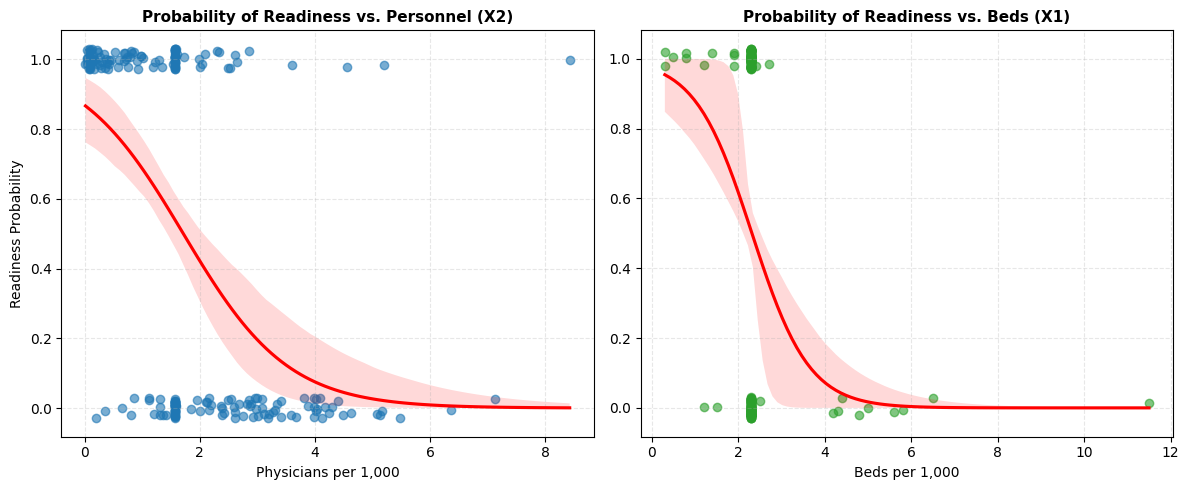

In [18]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🛡️ חסימת אזהרות ה-Overflow הנומריות של statsmodels ו-numpy
warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*overflow encountered.*')

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

# טעינת הנתונים
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# הגדרת המשתנים הרלוונטיים לצורך בניית דאטה נקי לגרף
desired_features = ['X1_hospital_beds', 'X2_physicians']
X_plot = pd.DataFrame(index=df_model.index)

for col in desired_features:
    if col in df_model.columns:
        X_plot[col] = df_model[col]
    else:
        X_plot[col] = 0.0

# מילוי ערכים חסרים (Imputation) מבוסס חציון בדיוק כמו במודל שלכן
for col in desired_features:
    if X_plot[col].isnull().sum() < len(X_plot):
        median_value = X_plot[col].median()
        X_plot[col] = X_plot[col].fillna(median_value)
    X_plot[col] = X_plot[col].fillna(0.0)

# הוספת משתנה המטרה חזרה לתוך הטבלה לצורך הציור
X_plot['Y_is_ready'] = df_model['Y_is_ready']

# =====================================================================
# הפקת הגרפים המעודכנים - נקיים מאזהרות
# =====================================================================
plt.figure(figsize=(12, 5))

# גרף א': קשר בין רופאים (X2) למוכנות
plt.subplot(1, 2, 1)
sns.regplot(x='X2_physicians', y='Y_is_ready', data=X_plot, logistic=True,
            y_jitter=0.03, scatter_kws={'alpha':0.6, 'color':'#1f77b4'}, line_kws={'color':'red'})
plt.title('Probability of Readiness vs. Personnel (X2)', fontsize=11, fontweight='bold')
plt.xlabel('Physicians per 1,000')
plt.ylabel('Readiness Probability')
plt.grid(True, linestyle='--', alpha=0.3)

# גרף ב': קשר בין מיטות (X1) למוכנות
plt.subplot(1, 2, 2)
sns.regplot(x='X1_hospital_beds', y='Y_is_ready', data=X_plot, logistic=True,
            y_jitter=0.03, scatter_kws={'alpha':0.6, 'color':'#2ca02c'}, line_kws={'color':'red'})
plt.title('Probability of Readiness vs. Beds (X1)', fontsize=11, fontweight='bold')
plt.xlabel('Beds per 1,000')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()

# שמירת הגרף הזוגי ישירות לדרייב כתמונה
regression_output_path = os.path.join(data_dir, 'readiness_regression_plots.png')
plt.savefig(regression_output_path, dpi=300, bbox_inches='tight')
print(f"🖼️ גרפי הרגרסיה הלוגיסטית הופקו ונשמרו בדרייב בנתיב:\n   {regression_output_path}\n")

plt.show()
